# Transformer for Multimodal Stock Forecasting
Implementation notebook for *Adaptive Portfolio Management in Volatile Markets with Multiplex Attention Transformers and Deep Reinforcement Learning*.

Code for **PyTorch** implementation of the Transformer proposed in our paper, trained to predict multi-step stock price trajectories from:
1. **Technical indicators** (OHLCV-derived)
2. **News‑sentiment embeddings** (from FinBERT)
3. **Macroeconomic features**

The model outputs \(H\)-step forecasts that later serve as inputs to the downstream RL trading agent.

In [1]:
!pip install -U torch torchvision torchaudio --quiet
!pip install -U transformers datasets peft --quiet
!pip install -U wandb --quiet
!pip install pytorch_lightning --quiet
!pip install pytorch_forecasting --quiet
!pip install darts --quiet
!pip install pandas_market_calendars --quiet

In [2]:
import darts
import math, os, random, json, itertools, warnings, datetime as dt, typing as typ
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import wandb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Running on', device)


Running on cuda


In [3]:
# some hyperparameters
WINDOW_SIZE = 30  # T
HORIZON_SIZE = 1  # H
BATCH_SIZE = 32
NUM_EPOCHS = 300
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-2
ALPHA         = 0.9      # weight for MSE vs BCE
GRAD_CLIP     = 2.0

# feature dimensions
TECH_DIM = 10
SENT_DIM = 1
MACRO_DIM = 3

In [63]:
# # init wandb
# wandb_api = "8736734cbf8541aa58ecb7f6776b57754d1c10d5"
# wandb.login(key=wandb_api)
# wandb.init(
#     project="transformer price forecast",
#     config={
#         "window": WINDOW_SIZE,
#         "horizon": HORIZON_SIZE,
#         "lr": 1e-4,
#     }
# )

## Data Processing

In [4]:
import pandas as pd, numpy as np
import pandas as pd, numpy as np, torch
from torch.utils.data import Dataset, DataLoader


def load_tensor(csv_path: str, feature_cols: list[str],
                tickers=None, dates=None):
    df = pd.read_csv(csv_path, parse_dates=['date'])

    if tickers is None: tickers = sorted(df['ticker'].unique())
    if dates   is None: dates   = sorted(df['date'].unique())

    df = (df.query('ticker in @tickers and date in @dates')
            .sort_values(['date', 'ticker']))

    mats = []
    for feat in feature_cols:
        mat = (df.pivot(index='date', columns='ticker', values=feat)
                 .reindex(index=dates, columns=tickers)
                 .astype('float32')
                 .fillna(0.0)   # replace missing with 0, try avoiding nan
                 .values)
        mats.append(mat[..., None])

    return np.concatenate(mats, axis=2), tickers, dates

class MultiCSVWindowDataset(Dataset):
    """
    Each sample = (x_stock, x_sent, x_macro, y)
    Shapes:
      x_* : [window, F]   (one ticker, consecutive dates)
      y   : [horizon, 1]  (open/close/high/low for next horizon days)
    """
    def __init__(self, npz_path: str, window: int = WINDOW_SIZE, horizon: int = HORIZON_SIZE):
        data = np.load(npz_path)
        self.stock  = data['tech']    # [D, N, F1]
        self.sent   = data['sent']    # [D, N, F2]
        self.macro  = data['macro']   # [D, N, F3]
        self.labels = data['price']   # [D, N, 1]

        self.T = window
        self.H = horizon
        self.D = self.stock.shape[0] - window - horizon
        self.N = self.stock.shape[1]

    def __len__(self):
        return self.D * self.N            # all (ticker, start‑time) pairs

    def __getitem__(self, idx):
        t0 = idx % self.D                 # time start
        k  = idx // self.D                # ticker index

        x_stock = self.stock [t0:t0+self.T, k, :]
        x_sent  = self.sent  [t0:t0+self.T, k, :]
        x_macro = self.macro[t0:t0+self.T, k, :]
        y = self.labels[t0+self.T:t0+self.T+self.H, k, :]   # horizon×4

        # previous day's true close:
        # this is for calculating accuracy only
        prev_close = self.labels[t0+self.T-1, k, 0]     # scalar

        # historical closes
        hist_close = self.labels[t0 : t0+self.T, k, 0]   # [T]

        return (torch.tensor(x_stock),
                torch.tensor(x_sent),
                torch.tensor(x_macro),
                torch.tensor(y),
                torch.tensor(prev_close),
                torch.tensor(hist_close))


# feature scaling (min‑max to 0‑1)
class MinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.min_ = None
        self.max_ = None
        self.data_min_ = None
        self.data_max_ = None
        self.feature_range = feature_range

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.data_min_ = X.min(axis=0)
        self.data_max_ = X.max(axis=0)
        self.min_ = self.feature_range[0]
        self.max_ = self.feature_range[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        scale = (self.max_ - self.min_) / (self.data_max_ - self.data_min_)
        X_scaled = self.min_ + (X - self.data_min_) * scale
        return X_scaled

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X_scaled):
        X_scaled = np.asarray(X_scaled, dtype=float)
        scale = (self.max_ - self.min_) / (self.data_max_ - self.data_min_)
        X_original = self.data_min_ + (X_scaled - self.min_) / scale
        return X_original


class DataPreprocessor():
    def __init__(self):
        self.scalers = {"tech": [], "sent": [], "macro": [], "label": []}

    def add_scalers(self, df_type: str, new_scalers: list):
        if df_type in self.scalers:
            self.scalers[df_type].extend(new_scalers)
        else:
            raise KeyError("dataframe type not supported!")

    def fit_transform(self, df_type: str, X):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_scaled = np.empty_like(X)
        days, stocks, features = X.shape

        for i in range(features):
            feature_data = X[:, :, i].reshape(-1, 1)  # (days * stocks, 1)
            X_scaled_feature = self.scalers[df_type][i].fit_transform(feature_data)
            X_scaled[:, :, i] = X_scaled_feature.reshape(days, stocks)

        return X_scaled

    def transform(self, df_type: str, X):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_scaled = np.empty_like(X)
        days, stocks, features = X.shape

        for i in range(features):
            feature_data = X[:, :, i].reshape(-1, 1)
            X_scaled_feature = self.scalers[df_type][i].transform(feature_data)
            X_scaled[:, :, i] = X_scaled_feature.reshape(days, stocks)

        return X_scaled

    def inverse_transform(self, df_type: str, X_scaled):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_orig = np.empty_like(X_scaled)
        days, stocks, features = X_scaled.shape

        for i in range(features):
            feature_data = X_scaled[:, :, i].reshape(-1, 1)
            X_orig_feature = self.scalers[df_type][i].inverse_transform(feature_data)
            X_orig[:, :, i] = X_orig_feature.reshape(days, stocks)

        return X_orig

    def process(self, tech_csv: str, sent_csv: str,
                           macro_csv: str, label_csv: str,
                           train_mode: bool, dataset_out_path: str):
        """
        Preprocesses tech, sent, macro, and label datasets.

        Args:
            tech_csv, sent_csv, macro_csv, label_csv: csv file paths
            train_mode: True for scalers to fit-transform, False for scalers to transform only
            dataset_out_path: file path to save output MultiCSVWindowDataset

        Returns:
            dataset: a MultiCSVWindowDataset
            loader: a DataLoader
        """

        tech_cols = ['volume','macd','boll_ub','boll_lb','rsi_30','cci_30',
                      'dx_30','close_30_sma','close_60_sma','vix']
        sent_cols  = ['sentiment']
        macro_cols = ['fedfunds','sp500','sector']
        label_cols = ['close']

        # build aligned tensors
        tech, tickers, dates  = load_tensor(tech_csv,  tech_cols) # tech.shape = (# dates, # tickers, # features)
        sent, _, _ = load_tensor(sent_csv,  sent_cols,  tickers, dates)
        macro, _, _  = load_tensor(macro_csv, macro_cols, tickers, dates)
        # print(macro.shape, type(macro), macro)

        #  build 4‑price cube (Date × Ticker)
        lbl_df = pd.read_csv(label_csv, parse_dates=['date'])
        lbl_df = (
            lbl_df.query('ticker in @tickers and date in @dates')
                  .sort_values(['date', 'ticker'])
        )

        label_mats = []
        for col in label_cols:         # ['close']
            mat = (lbl_df.pivot(index='date', columns='ticker', values=col)
                          .reindex(index=dates, columns=tickers)     # enforce exact order
                          .astype('float32')
                          .values)                                   # (D, N)
            label_mats.append(mat[..., None])                        # add 1‑len feature axis

        label = np.concatenate(label_mats, axis=2)         # (D, N, 1)
        # print(label.shape, type(label), label)
        self.add_scalers("tech", [MinMaxScaler() for col in tech_cols])
        self.add_scalers("sent", [MinMaxScaler() for col in sent_cols])
        self.add_scalers("macro", [MinMaxScaler() for col in macro_cols])
        self.add_scalers("label", [MinMaxScaler() for col in label_cols])
        if train_mode:
            tech_scaled = self.fit_transform(df_type = "tech", X = tech)
            sent_scaled = self.fit_transform(df_type = "sent", X = sent)
            macro_scaled = self.fit_transform(df_type = "macro", X = macro)
            label_scaled = self.fit_transform(df_type = "label", X = label)
        else:
            tech_scaled = self.transform(df_type = "tech", X = tech)
            sent_scaled = self.transform(df_type = "sent", X = sent)
            macro_scaled = self.transform(df_type = "macro", X = macro)
            label_scaled = self.transform(df_type = "label", X = label)
        # print(label_scaled.shape, label_scaled)


        np.savez_compressed(
            dataset_out_path,
            tech=tech_scaled, sent=sent_scaled,
            macro=macro_scaled, price=label)


        dataset = MultiCSVWindowDataset(dataset_out_path, window=WINDOW_SIZE, horizon=HORIZON_SIZE)
        loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        return dataset, loader




In [5]:
# get train data
data_preprocessor = DataPreprocessor()
dataset, loader = data_preprocessor.process(tech_csv="test_stock.csv",
                                            sent_csv="test_sentiment.csv",
                                            macro_csv="test_macro.csv",
                                            label_csv="test_stock.csv",
                                            train_mode=True,
                                            dataset_out_path="aligned_data_train.npz")

# right after building train_dataset, check shape
x_s, x_se, x_m, y, close, hist_close = dataset[0]
print(y)
print(close)
print("First train window shapes:", x_s.shape, x_se.shape, x_m.shape, y.shape)
print(" First target (raw):", data_preprocessor.inverse_transform("label", y.unsqueeze(0)).round())
print(" First features peek:", x_s[-1, :3].round())  # last time‐step stock features


# get val data
dataset, loader = data_preprocessor.process(tech_csv="val_stock.csv",
                                            sent_csv="val_sentiment.csv",
                                            macro_csv="val_macro.csv",
                                            label_csv="val_stock.csv",
                                            train_mode=False,
                                            dataset_out_path="aligned_data_val.npz")


data = np.load('aligned_data_train.npz')
prices = data['price']        # shape [D, N, 1]
price_min = float(prices.min())
price_max = float(prices.max())



tensor([[185.6560]])
tensor(182.4368)
First train window shapes: torch.Size([30, 10]) torch.Size([30, 1]) torch.Size([30, 3]) torch.Size([1, 1])
 First target (raw): [[[122702.]]]
 First features peek: tensor([0., 1., 0.])


## Multiplex Attention Block

In [67]:

# class MultiplexAttention(nn.Module):
#     """Applies self‑attention independently to three modality streams and concatenates the results."""

#     def __init__(self, dim: int, num_heads: int):
#         super().__init__()
#         self.dim = dim
#         self.num_heads = num_heads
#         self.attn_stock = nn.MultiheadAttention(dim, num_heads, batch_first=True)
#         self.attn_sent  = nn.MultiheadAttention(dim, num_heads, batch_first=True)
#         self.attn_macro = nn.MultiheadAttention(dim, num_heads, batch_first=True)
#         # projection after concat of 3*dim back to dim
#         self.out_proj   = nn.Linear(3*dim, dim)
#         #self.norm = nn.LayerNorm(dim)



#     def forward(self, x_stock, x_sent, x_macro, key_padding_mask=None):
#         seq_len = x_stock.size(1)
#         attn_mask = torch.triu(torch.ones(seq_len, seq_len) * float('-inf'), diagonal=1).to(x_stock.device)

#         # each input: [B, T, D]
#         a_stock, _ = self.attn_stock(x_stock, x_stock, x_stock,
#                                      key_padding_mask=key_padding_mask,
#                                      attn_mask=attn_mask)
#         a_sent,  _ = self.attn_sent(x_sent, x_sent, x_sent,
#                                     key_padding_mask=key_padding_mask,
#                                     attn_mask=attn_mask)
#         a_macro, _ = self.attn_macro(x_macro, x_macro, x_macro,
#                                      key_padding_mask=key_padding_mask,
#                                      attn_mask=attn_mask)
#         # concat on last dim
#         cat = torch.cat([a_stock, a_sent, a_macro], dim=-1)
#         out = self.out_proj(cat)
#         #return self.norm(out)
#         return out


## Transformer Forecasting Model

In [70]:

# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model: int, max_len: int = 5000):
#         super().__init__()
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0)  # [1, max_len, d_model]
#         self.register_buffer('pe', pe)
#     def forward(self, x):
#         x = x + self.pe[:, :x.size(1), :]
#         return x

# class MultiplexTransformerForecaster(nn.Module):
#     def __init__(self,
#                  dim: int = 128,
#                  num_heads: int = 4,
#                  num_layers: int = 4,
#                  horizon: int = HORIZON_SIZE,
#                  dropout: float = 0.2,
#                  tech_dim:  int = TECH_DIM,
#                  sent_dim:  int = SENT_DIM,
#                  macro_dim: int = MACRO_DIM,
#                  window:    int = WINDOW_SIZE):
#         super().__init__()
#         self.horizon = horizon
#         self.window  = window
#         self.attn_norm = nn.LayerNorm(dim)

#         # modality‑specific projections
#         self.embed_stock = nn.Linear(tech_dim,  dim)
#         self.embed_sent  = nn.Linear(sent_dim,  dim)
#         self.embed_macro = nn.Linear(macro_dim, dim)

#         self.pos_enc = PositionalEncoding(dim)

#         blocks = []
#         for _ in range(num_layers):
#             blocks.append(MultiplexAttention(dim, num_heads))
#             blocks.append(nn.Sequential(
#                 nn.LayerNorm(dim),
#                 nn.Linear(dim, dim*4), nn.GELU(),
#                 nn.Dropout(dropout),
#                 nn.Linear(dim*4, dim)
#             ))
#         self.layers = nn.ModuleList(blocks)

#         # prediction head: produce horizon × 4 prices, not just horizon
#         self.pred_head = nn.Sequential(
#             nn.LayerNorm(dim),
#             nn.Flatten(start_dim=1),                      # [B, window*dim]
#             nn.Linear(dim * window, horizon * 4)
#         )



#     def forward(self, x_stock, x_sent, x_macro):          # [B, T, F*]
#         s = self.embed_stock(x_stock)
#         t = self.embed_sent(x_sent)
#         m = self.embed_macro(x_macro)

#         s, t, m = map(self.pos_enc, (s, t, m))

#         for blk in self.layers:
#             if isinstance(blk, MultiplexAttention):
#                 residual = s
#                 s = t = m = blk(s, t, m)
#                 s = s + residual
#                 s = self.attn_norm(s)
#             else:                         # feed‑forward
#                 s = s + blk(s)
#                 t = m = s

#         # price prediction
#         price_logits = self.pred_head(s)        # [B, horizon*4]
#         price_pred   = price_logits.view(-1, self.horizon, 4)

#         return price_pred


In [79]:
# # try this one instead
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
#         super().__init__()
#         self.dropout = nn.Dropout(dropout)
#         # create constant 'pe' matrix with values dependent on pos and i
#         pe = torch.zeros((max_len, d_model))
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(
#             torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
#         )
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0)  # shape [1, max_len, d_model]
#         self.register_buffer('pe', pe)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         # x shape: [batch_size, seq_len, d_model]
#         x = x + self.pe[:, :x.size(1)]
#         return self.dropout(x)

# class ImprovedTransformerForecaster(nn.Module):
#     def __init__(
#         self,
#         tech_dim: int,
#         sent_dim: int,
#         macro_dim: int,
#         d_model: int = 256,
#         n_heads: int = 4,
#         n_layers: int = 4,
#         window: int = WINDOW_SIZE,
#         dropout: float = 0.1,
#     ):
#         super().__init__()
#         self.window = window
#         total_dim = tech_dim + sent_dim + macro_dim
#         self.input_proj = nn.Linear(total_dim, d_model)
#         self.pos_enc    = PositionalEncoding(d_model, dropout, max_len=window)
#         enc_layer = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=n_heads,
#             dim_feedforward=d_model * 4,
#             dropout=dropout,
#             activation='gelu'
#         )
#         self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
#         self.head = nn.Sequential(
#             nn.LayerNorm(d_model),
#             nn.Linear(d_model, 1)
#         )

#     def forward(
#         self,
#         x_tech: torch.Tensor,
#         x_sent: torch.Tensor,
#         x_macro: torch.Tensor
#     ) -> torch.Tensor:
#         # x_* shapes: [B, T, F]
#         x = torch.cat([x_tech, x_sent, x_macro], dim=-1)  # [B, T, total_dim]
#         x = self.input_proj(x)                           # [B, T, d_model]
#         x = self.pos_enc(x)                              # [B, T, d_model]
#         x = x.transpose(0, 1)                            # [T, B, d_model]
#         x = self.transformer(x)                          # [T, B, d_model]
#         x = x.transpose(0, 1)                            # [B, T, d_model]
#         return self.head(x)                              # [B, T, 1]



### Inject LoRA Adapters

In [24]:

# Uncomment to add LoRA adapters if `peft` is installed in environment
# from peft import get_peft_model, LoraConfig, TaskType
# lora_cfg = LoraConfig(
#     task_type=TaskType.FEATURE_EXTRACTION,
#     target_modules=['q_proj', 'k_proj', 'v_proj'],
#     r=8, lora_alpha=32, lora_dropout=0.05)
# model = MultiplexTransformerForecaster().to(device)
# model = get_peft_model(model, lora_cfg)


## Training Loop

In [83]:
# # def train_epoch(model, loader, optimizer, scaler,
# #                 mse_loss, bce_loss,
# #                 alpha=0.8, grad_clip=2.0):
# #     model.train()
# #     total_loss = 0.0
# #     total_correct = 0
# #     total_samples = 0
# #     scaling_factor = 1    # scale BCE to match MSE magnitude
# #     eps = 1e-6  # define once

# #     # move min/max tensors once
# #     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
# #     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

# #     for x_stock, x_sent, x_macro, y, prev_close, hist_close in loader:
# #         # to device & reshape
# #         x_stock, x_sent, x_macro = [t.to(device) for t in (x_stock, x_sent, x_macro)]
# #         y          = y.to(device).squeeze(-1)     # [B, H]
# #         prev_close = prev_close.to(device)        # [B]

# #         # forward
# #         y_hat = model(x_stock, x_sent, x_macro)   # [B, H, 1]

# #         # regression loss
# #         Lmse = mse_loss(y_hat, y.unsqueeze(-1))   # [B,H,1]

# #         hist_close = hist_close.to(device)

# #         # compute returns over the window
# #         # simple pct‐change:
# #         rets = (hist_close[:, 1:] - hist_close[:, :-1]) \
# #                  / (hist_close[:, :-1] + eps)      # [B, T-1]
# #         vol = rets.std(dim=1)                    # [B], sample volatility

# #         # forward & regression as before
# #         y_hat = model(x_stock, x_sent, x_macro)  # [B,H,1]
# #         y_denorm = y_hat * (pM - pm) + pm        # [B,H,1]
# #         pred0 = y_denorm[:,0,0]                  # [B]

# #         # normalized logit
# #         logit = (pred0 - prev_close) / (vol + eps)  # [B]

# #         # now BCE on this standardized logit
# #         true_up = (y[:,0] > prev_close).float()
# #         Lbce    = bce_loss(logit, true_up)

# #         # 4) combined loss & backward
# #         loss = alpha * Lmse + (1 - alpha) * (scaling_factor * Lbce)
# #         optimizer.zero_grad()
# #         scaler.scale(loss).backward()
# #         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
# #         scaler.step(optimizer)
# #         scaler.update()

# #         # 5) metrics
# #         B = y.size(0)
# #         total_samples  += B
# #         total_loss     += loss.item() * B
# #         preds = (logit > 0).float()
# #         total_correct += (preds == true_up).sum().item()
# #         #print(f"MSE={Lmse.item():.1f}  BCE={Lbce.item():.4f}  scaled BCE={(scaling_factor*Lbce).item():.1f}")


# #     return total_loss / total_samples, total_correct / total_samples


# # def evaluate_epoch(model, loader, mse_loss, bce_loss, current_epoch):
# #     model.eval()
# #     total_loss = 0.0
# #     total_samples = 0
# #     total_correct = 0

# #     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
# #     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

# #     logged = False

# #     with torch.no_grad():
# #         for x_stock, x_sent, x_macro, y, prev_close, hist_close in loader:
# #             x_stock, x_sent, x_macro = [t.to(device) for t in (x_stock, x_sent, x_macro)]
# #             y          = y.to(device).squeeze(-1)
# #             prev_close = prev_close.to(device)

# #             # forward
# #             y_hat = model(x_stock, x_sent, x_macro)   # [B,H,1]

# #             # regression loss
# #             Lmse = mse_loss(y_hat, y.unsqueeze(-1))

# #             # build logit
# #             y_denorm = y_hat * (pM - pm) + pm
# #             logit    = (y_denorm[:, 0, 0] - prev_close)
# #             true_up  = (y[:, 0] > prev_close).float()
# #             Lbce     = bce_loss(logit, true_up)

# #             # optionally track combined loss or just MSE
# #             loss = Lmse + Lbce  # or loss = Lmse

# #             B = y.size(0)
# #             total_samples += B
# #             total_loss    += loss.item() * B

# #             preds = (logit > 0).float()
# #             total_correct += (preds == true_up).sum().item()

# #     return total_loss / total_samples, total_correct / total_samples




# def train_epoch():
#     model.train()
#     total_loss = total_correct = total_samples = 0
#     eps = 1e-6
#     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
#     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

#     for x_s, x_t, x_m, y, prev_close, hist in train_loader:
#         x_s, x_t, x_m = [t.to(device) for t in (x_s, x_t, x_m)]
#         y          = y.to(device).squeeze(-1)  # [B, H]
#         prev_close = prev_close.to(device)
#         hist       = hist.to(device)

#         y_hat = model(x_s, x_t, x_m)           # [B, H, 1]
#         Lmse  = mse_loss(y_hat, y.unsqueeze(-1))

#         rets = (hist[:,1:] - hist[:,:-1]) / (hist[:,:-1] + eps)
#         vol  = rets.std(dim=1)

#         y_denorm = y_hat * (pM - pm) + pm      # [B,H,1]
#         pred0    = y_denorm[:,0,0]
#         logit    = (pred0 - prev_close) / (vol + eps)
#         true_up  = (y[:,0] > prev_close).float()
#         Lbce     = bce_loss(logit, true_up)

#         loss = ALPHA * Lmse + (1-ALPHA)*Lbce
#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
#         optimizer.step()
#         scheduler.step()

#         B = y.size(0)
#         total_samples += B
#         total_loss    += loss.item() * B
#         total_correct += ((logit>0).float() == true_up).sum().item()

#     return total_loss/total_samples, total_correct/total_samples


# def evaluate_epoch(epoch):
#     model.eval()
#     total_loss = total_correct = total_samples = 0
#     pm = torch.tensor(price_min, dtype=torch.float32, device=device)
#     pM = torch.tensor(price_max, dtype=torch.float32, device=device)

#     with torch.no_grad():
#         for x_s, x_t, x_m, y, prev_close, hist in val_loader:
#             x_s, x_t, x_m = [t.to(device) for t in (x_s, x_t, x_m)]
#             y          = y.to(device).squeeze(-1)
#             prev_close = prev_close.to(device)

#             y_hat = model(x_s, x_t, x_m)
#             Lmse  = mse_loss(y_hat, y.unsqueeze(-1))

#             y_denorm = y_hat * (pM - pm) + pm
#             logit    = (y_denorm[:,0,0] - prev_close)
#             true_up  = (y[:,0] > prev_close).float()
#             Lbce     = bce_loss(logit, true_up)

#             loss = Lmse + Lbce
#             B = y.size(0)
#             total_samples += B
#             total_loss    += loss.item() * B
#             total_correct += ((logit>0).float() == true_up).sum().item()


#     return total_loss/total_samples, total_correct/total_samples

In [14]:
# train_ds = MultiCSVWindowDataset('aligned_data_train.npz', WINDOW_SIZE, HORIZON_SIZE)
# val_ds   = MultiCSVWindowDataset('aligned_data_val.npz',   WINDOW_SIZE, HORIZON_SIZE)
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = ImprovedTransformerForecaster(
#     tech_dim=train_ds.stock.shape[-1],
#     sent_dim=train_ds.sent.shape[-1],
#     macro_dim=train_ds.macro.shape[-1]
# ).to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=LEARNING_RATE,
#     total_steps=NUM_EPOCHS * len(train_loader),
#     pct_start=0.1,
#     anneal_strategy='cos'
# )
# mse_loss = nn.MSELoss()
# bce_loss = nn.BCEWithLogitsLoss()



# all_up = []
# for _,_,_,y,prev,hist_prev in val_loader:
#     y, prev = y.squeeze(-1).to(device), prev.to(device)
#     all_up.append((y[:,0] > prev).long())
# all_up = torch.cat(all_up)
# print("Up fraction:", all_up.float().mean().item())

# for epoch in range(NUM_EPOCHS):
#     train_loss, train_acc = train_epoch()
#     val_loss, val_acc = evaluate_epoch(epoch)
#     print(f'Epoch {epoch+1}: train MSE = {train_loss:.4f}, val MSE = {val_loss:.4f}, train acc = {train_acc:.4f}, val acc = {val_acc:.4f}')


# Cross-Validation

In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [80]:


def cross_validate(dataset, param_grid, folds=3, epochs=10):
    results = []
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)

    for params in param_grid:
        fold_losses = []
        for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
            train_subset = Subset(dataset, train_idx)
            val_subset = Subset(dataset, val_idx)

            train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, drop_last=True)
            val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, drop_last=False)

            model = MultiplexTransformerForecaster(
                tech_dim=TECH_DIM,
                sent_dim=SENT_DIM,
                macro_dim=MACRO_DIM,
                window=WINDOW_SIZE,
                horizon=HORIZON_SIZE,
                **params
            ).to(device)

            optimizer = optim.AdamW(model.parameters(), lr=params.get('lr', 1e-4), weight_decay=1e-2)
            scaler = torch.cuda.amp.GradScaler()
            loss_fn = nn.MSELoss()

            for epoch in range(epochs):
                train_epoch(model, train_loader, optimizer, scaler, loss_fn)

            val_loss = evaluate_epoch(model, val_loader, loss_fn)
            fold_losses.append(val_loss)

        avg_loss = np.mean(fold_losses)
        results.append((params, avg_loss))
        print(f"Params: {params}, Avg Val Loss: {avg_loss:.4f}")

    best_params = min(results, key=lambda x: x[1])[0]
    print(f"\nBest Hyperparameters: {best_params}")
    return best_params, results

In [ ]:
param_grid = [
    {"dropout": 0.1, "dim": 128, "num_heads":4},
    {"dropout": 0.2, "dim": 256, "num_heads":8},
]

In [ ]:
best_params, results = cross_validate(dataset, param_grid, folds=3, epochs=10)


# TFT Forecasting

In [13]:
# TFT forecasting with Darts for multi-stock data using covariates

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import TFTModel
from darts.utils.likelihood_models import QuantileRegression
from darts.dataprocessing.transformers import Scaler
import warnings
import pandas_market_calendars as mcal


warnings.filterwarnings('ignore')

# hyperparameters and data paths
NPZ_TRAIN = 'aligned_data_train.npz'
NPZ_VAL   = 'aligned_data_val.npz'
INPUT_CHUNK_LENGTH = 30
FORECAST_HORIZON   = 5
BATCH_SIZE         = 32
N_EPOCHS           = 30   # change after
RANDOM_STATE       = 42
num_tickers = 30
train_npz = np.load(NPZ_TRAIN)
val_npz   = np.load(NPZ_VAL)
days_train, num_tickers, _ = train_npz['price'].shape
days_val   = val_npz['price'].shape[0]
# market calendar
nyse = mcal.get_calendar("NYSE")
schedule_train = nyse.schedule(start_date="2024-04-01", end_date="2025-03-31")
dates_train    = schedule_train.index
schedule_val   = nyse.schedule(start_date="2020-07-01", end_date="2024-03-31")
dates_val      = schedule_val.index



# flatten dates and symbols
symbols = np.array([f"stock_{t}" for t in range(num_tickers)])
flat_dates_train  = np.repeat(dates_train, num_tickers)
flat_symbols_train = np.tile(symbols, days_train)
# flatten price and covariates
price_train_flat = train_npz['price'][:,:,0].flatten()
tech_flat  = train_npz['tech'].reshape(days_train * num_tickers, -1)
sent_flat  = train_npz['sent'].reshape(days_train * num_tickers, -1)
macro_flat = train_npz['macro'].reshape(days_train * num_tickers, -1)
cov_train_flat = np.concatenate([tech_flat, sent_flat, macro_flat], axis=1)
# column names
tech_cols  = [f"tech_{i}"  for i in range(tech_flat.shape[1])]
sent_cols  = [f"sent_{i}"  for i in range(sent_flat.shape[1])]
macro_cols = [f"macro_{i}" for i in range(macro_flat.shape[1])]
cov_cols   = tech_cols + sent_cols + macro_cols
# build DataFrame
df_train = pd.DataFrame(cov_train_flat, columns=cov_cols)
df_train['date']   = flat_dates_train
df_train['symbol'] = flat_symbols_train
df_train['price']  = price_train_flat
# reorder columns
df_train = df_train[['date','symbol','price'] + cov_cols]

# VALIDATION DataFrame
flat_dates_val   = np.repeat(dates_val, num_tickers)
flat_symbols_val = np.tile(symbols, days_val)
price_val_flat = val_npz['price'][:,:,0].flatten()
tech_flat_val  = val_npz['tech'].reshape(days_val * num_tickers, -1)
sent_flat_val  = val_npz['sent'].reshape(days_val * num_tickers, -1)
macro_flat_val = val_npz['macro'].reshape(days_val * num_tickers, -1)
cov_val_flat = np.concatenate([tech_flat_val, sent_flat_val, macro_flat_val], axis=1)
# build DataFrame
df_val = pd.DataFrame(cov_val_flat, columns=cov_cols)
df_val['date']   = flat_dates_val
df_val['symbol'] = flat_symbols_val
df_val['price']  = price_val_flat
# reorder columns
df_val = df_val[['date','symbol','price'] + cov_cols]

# Create a custom business day frequency from NYSE holidays
from pandas.tseries.offsets import CustomBusinessDay
nyse_cal = mcal.get_calendar("NYSE")
holidays = nyse_cal.holidays().holidays
custom_bd = CustomBusinessDay(holidays=holidays)

# Use this custom frequency and do NOT fill missing dates
freq = custom_bd

# create TimeSeries lists
ts_train_list = TimeSeries.from_group_dataframe(
    df=df_train,
    group_cols=['symbol'],
    time_col='date',
    value_cols=['price'],
    freq=freq,
    fill_missing_dates=True  # allow Darts to infer freq from irregular trading days
)  # was fill_missing_dates=False

ts_val_list = TimeSeries.from_group_dataframe(
    df=df_val,
    group_cols=['symbol'],
    time_col='date',
    value_cols=['price'],
    freq=freq,
    fill_missing_dates=True
)  # was fill_missing_dates=False
ts_val_list = TimeSeries.from_group_dataframe(
    df=df_val,
    group_cols=['symbol'],
    time_col='date',
    value_cols=['price'],
    freq=freq,
    fill_missing_dates=False
)

# convert to dicts
train_target = {ts.static_covariates['symbol'][0]: ts for ts in ts_train_list}
val_target   = {ts.static_covariates['symbol'][0]: ts for ts in ts_val_list}

# also build covariate dicts by dropping 'price'
cov_cols = [c for c in df_train.columns if c not in ['date','symbol','price']]
ts_train_cov = TimeSeries.from_group_dataframe(
    df=df_train,
    group_cols=['symbol'],
    time_col='date',
    value_cols=cov_cols,
    freq=freq,
    fill_missing_dates=False
)
ts_val_cov = TimeSeries.from_group_dataframe(
    df=df_val,
    group_cols=['symbol'],
    time_col='date',
    value_cols=cov_cols,
    freq=freq,
    fill_missing_dates=False
)
train_past_cov = { ts.static_covariates['symbol'][0]: ts for ts in ts_train_cov }
val_past_cov   = { ts.static_covariates['symbol'][0]: ts for ts in ts_val_cov }

# align dicts to lists for model.fit
symbols = sorted(train_target.keys())
train_target_list      = [train_target[s] for s in symbols]
train_past_cov_list    = [train_past_cov[s] for s in symbols]
val_target_list        = [val_target[s] for s in symbols]
val_past_cov_list      = [val_past_cov[s] for s in symbols]



# Debug: print date ranges for each training series
for ts in ts_train_list:
    symbol = ts.static_covariates['symbol'][0]
    print(f"Train series for {symbol}: {ts.start_time()} to {ts.end_time()}")

# Debug: print date ranges for each validation series
for ts in ts_val_list:
    symbol = ts.static_covariates['symbol'][0]
    print(f"Validation series for {symbol}: {ts.start_time()} to {ts.end_time()}")  # was fill_missing_dates=False



Train series for stock_0: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_1: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_10: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_11: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_12: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_13: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_14: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_15: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_16: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_17: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_18: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_19: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_2: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_20: 2024-04-01 00:00:00 to 2025-03-31 00:00:00
Train series for stock_

In [10]:
# instantiate and fit TFTModel
quantiles = np.arange(0.01, 1.0, 0.01).tolist()
likelihood = QuantileRegression(quantiles=quantiles)
model = TFTModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=FORECAST_HORIZON,
    hidden_size=64,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.1,
    batch_size=BATCH_SIZE,
    n_epochs=300,
    add_relative_index=True,
    add_encoders=None,
    likelihood=likelihood,
    random_state=RANDOM_STATE,
    use_static_covariates=False,
    force_reset=True,
    pl_trainer_kwargs={
        'accelerator': 'cpu',
        'gradient_clip_val': 0.05,
        'enable_progress_bar': True,
        'max_epochs': N_EPOCHS,
        'check_val_every_n_epoch': 1,
        'log_every_n_steps': 10,
        'logger': True
    }
)
model.fit(
    series=train_target_list,
    past_covariates=train_past_cov_list,
    val_series=val_target_list,
    val_past_covariates=val_past_cov_list,
    verbose=True
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 30.1 K | train
5  | decoder_vsn                       | _VariableSelectionNetw

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, loss_fn=None, likelihood=QuantileRegression(quantiles=[0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.06999999999999999, 0.08, 0.09, 0.09999999999999999, 0.11, 0.12, 0.13, 0.14, 0.15000000000000002, 0.16, 0.17, 0.18000000000000002, 0.19, 0.2, 0.21000000000000002, 0.22, 0.23, 0.24000000000000002, 0.25, 0.26, 0.27, 0.28, 0.29000000000000004, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35000000000000003, 0.36000000000000004, 0.37, 0.38, 0.39, 0.4, 0.41000000000000003, 0.42000000000000004, 0.43, 0.44, 0.45, 0.46, 0.47000000000000003, 0.48000000000000004, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.5700000000000001, 0.5800000000000001, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.6900000000000001, 0.7000000000000001, 0.7100000000000001, 0.7

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


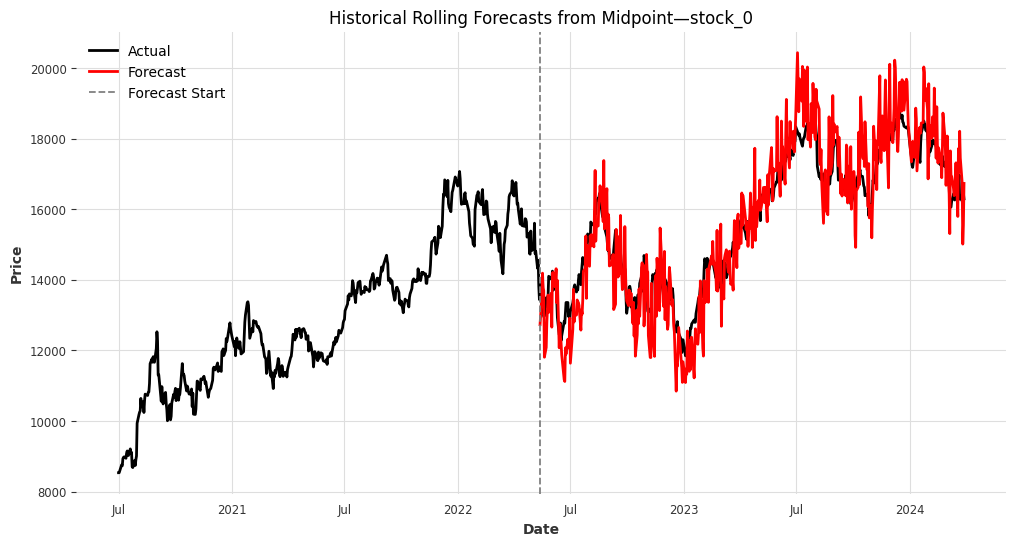

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_0: MAPE=4.33%, SMAPE=4.33%, MAE=669.5338


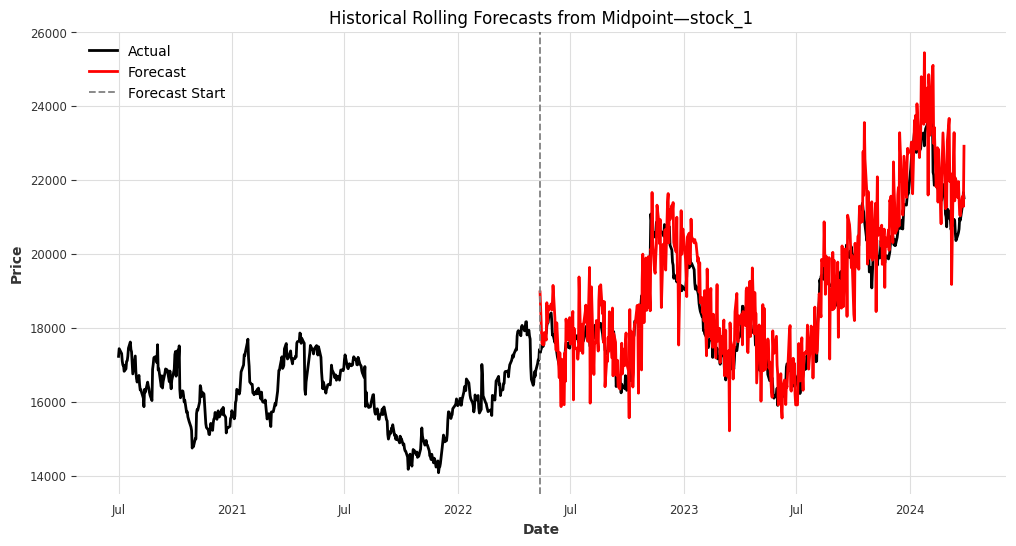

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_1: MAPE=3.76%, SMAPE=3.71%, MAE=712.2639


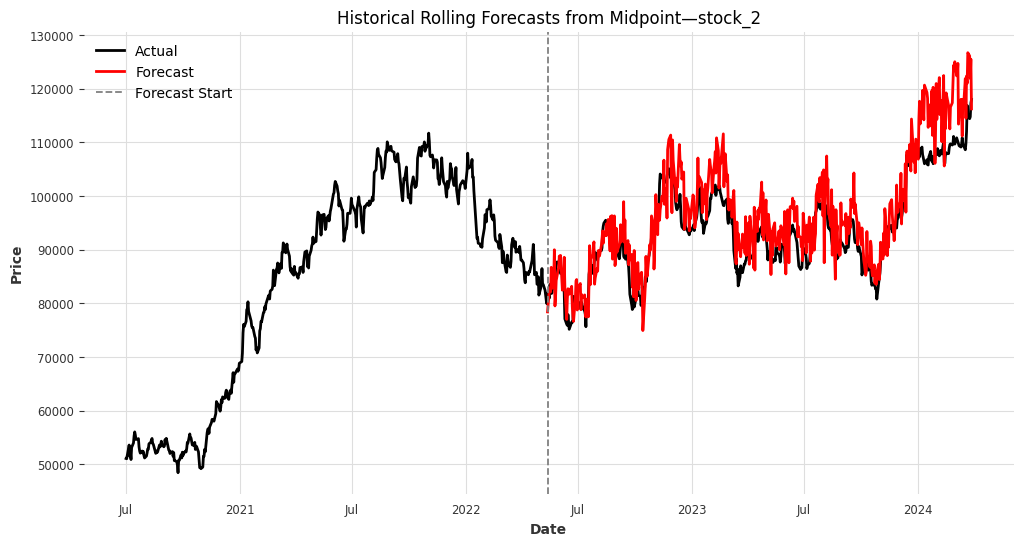

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_2: MAPE=4.59%, SMAPE=4.47%, MAE=4358.8462


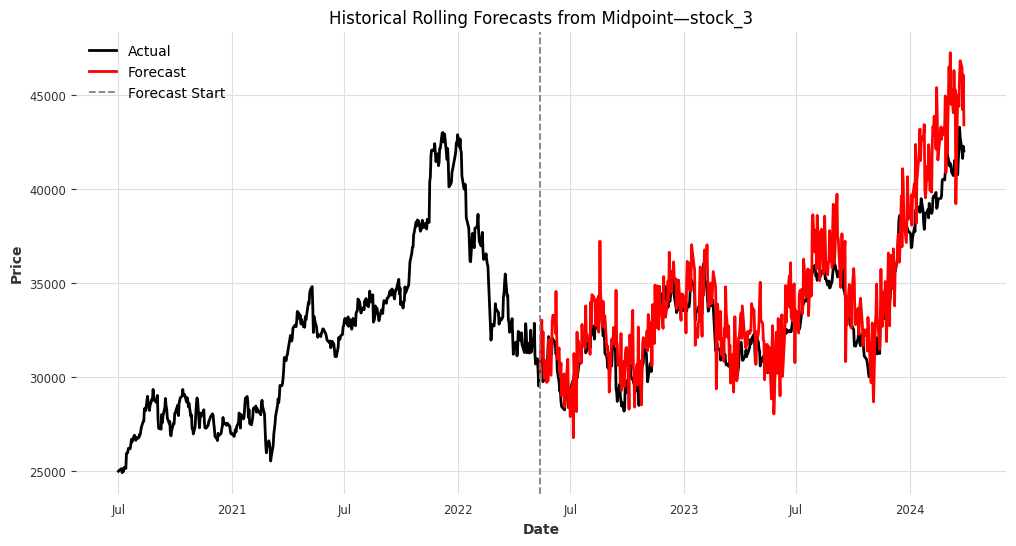

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_3: MAPE=4.36%, SMAPE=4.25%, MAE=1479.8474


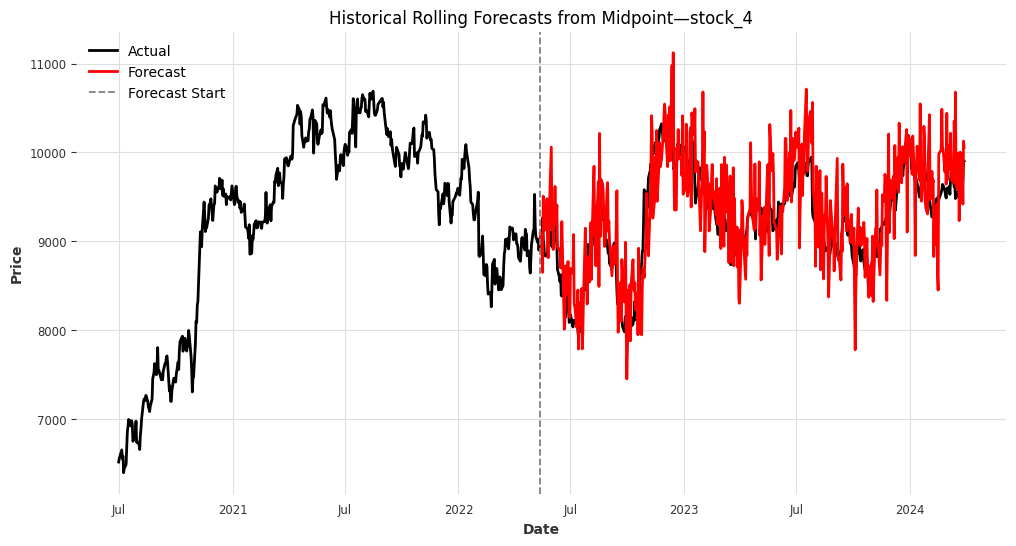

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_4: MAPE=3.63%, SMAPE=3.60%, MAE=334.2269


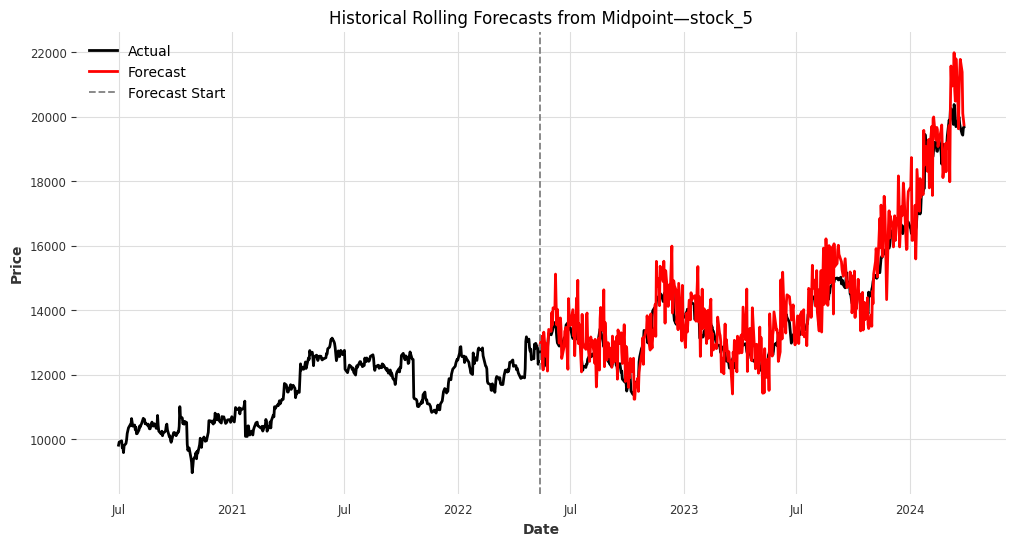

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_5: MAPE=4.07%, SMAPE=4.00%, MAE=578.5689


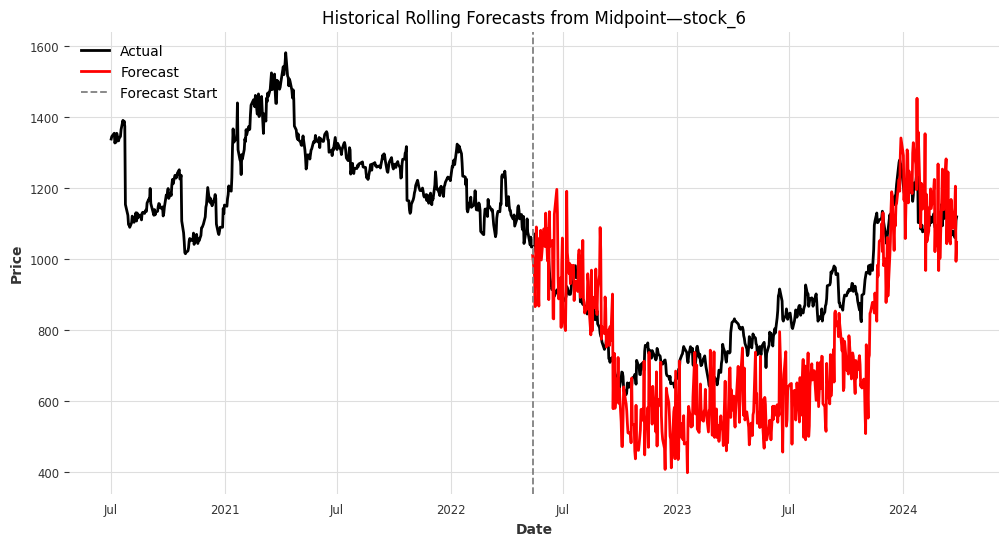

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_6: MAPE=17.45%, SMAPE=19.69%, MAE=144.8425


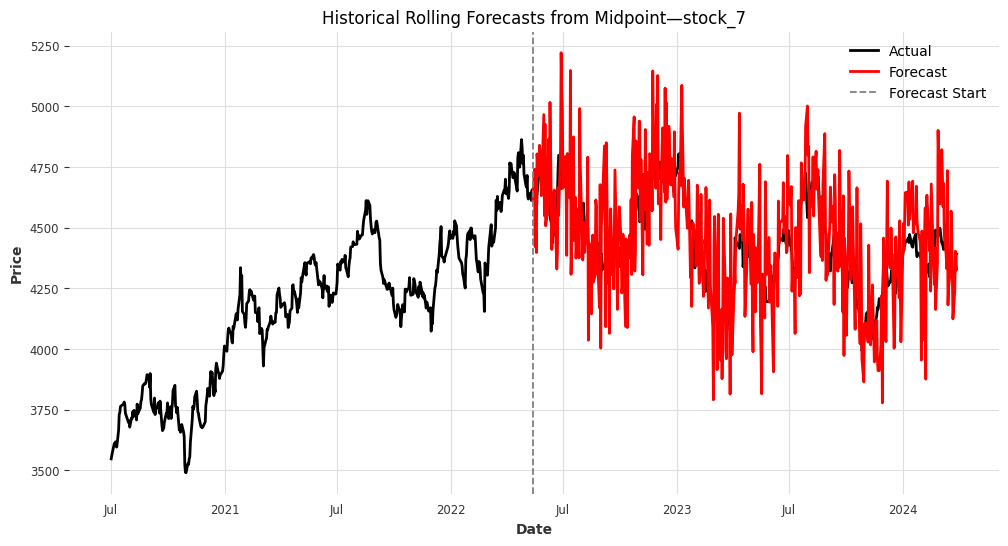

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_7: MAPE=3.64%, SMAPE=3.61%, MAE=160.5996


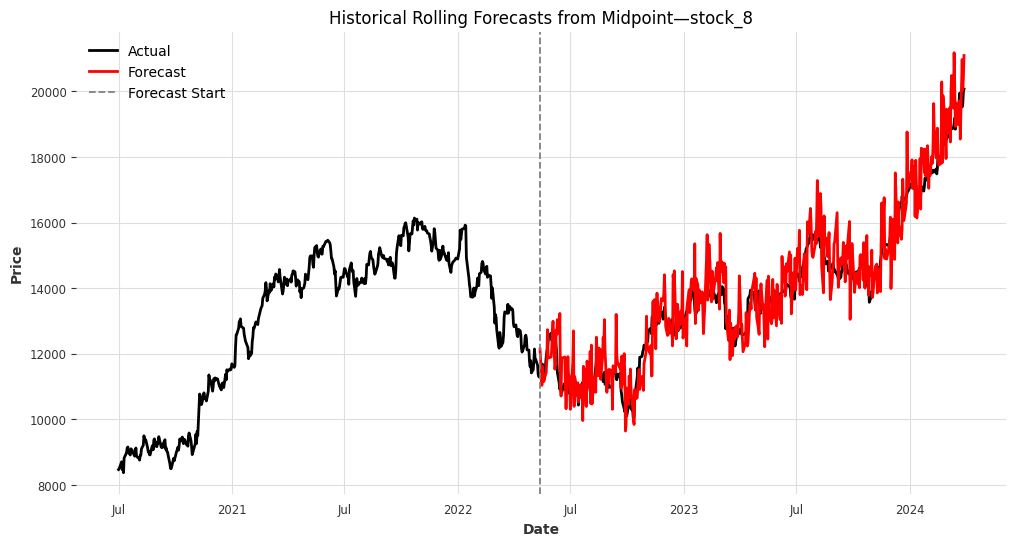

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_8: MAPE=4.29%, SMAPE=4.23%, MAE=586.4265


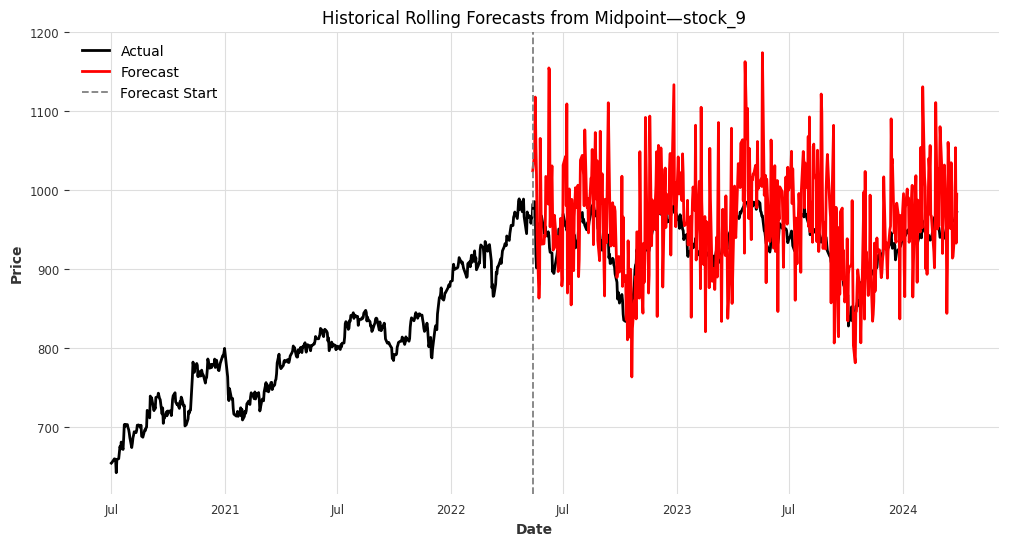

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_9: MAPE=5.66%, SMAPE=5.50%, MAE=52.8394


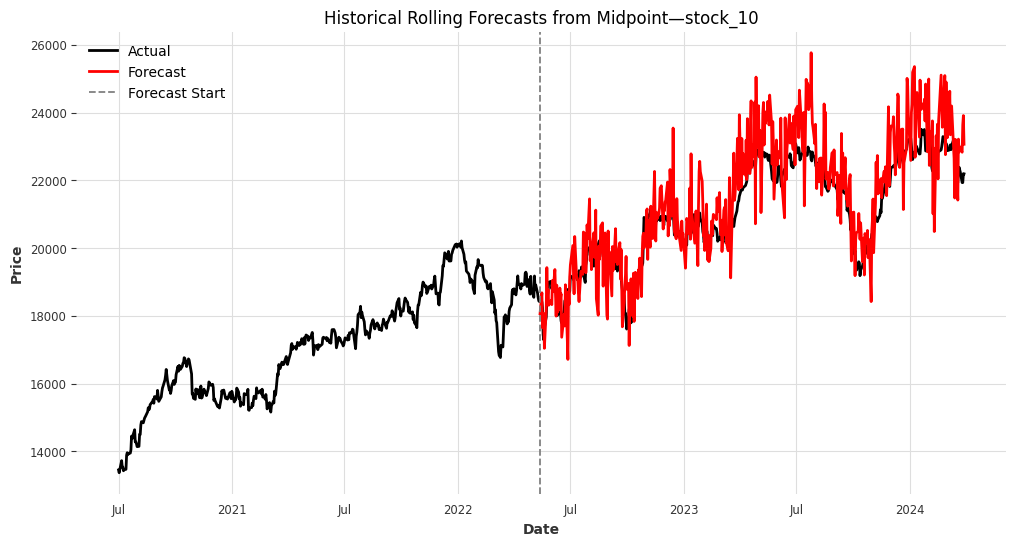

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_10: MAPE=3.54%, SMAPE=3.47%, MAE=750.8739


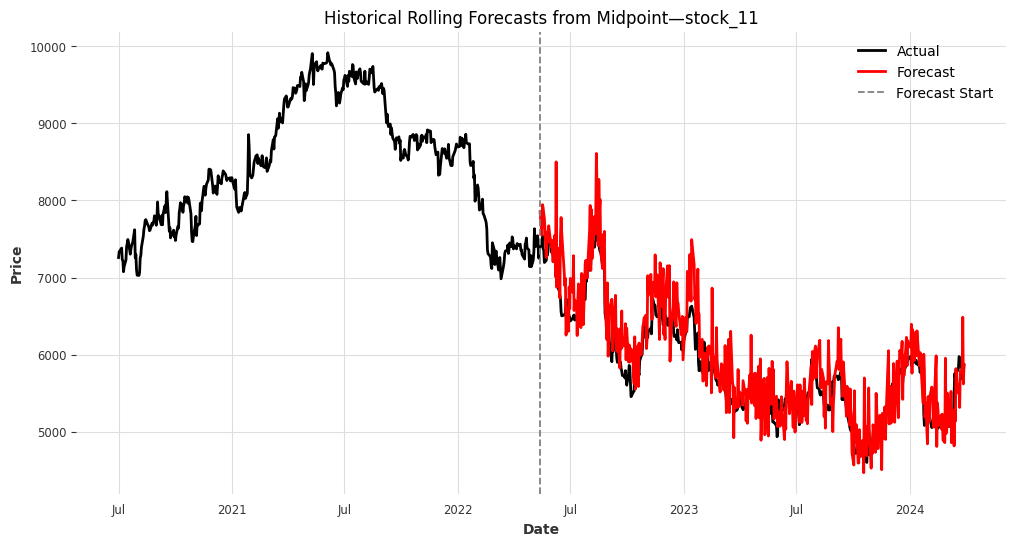

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_11: MAPE=5.08%, SMAPE=4.95%, MAE=294.7406


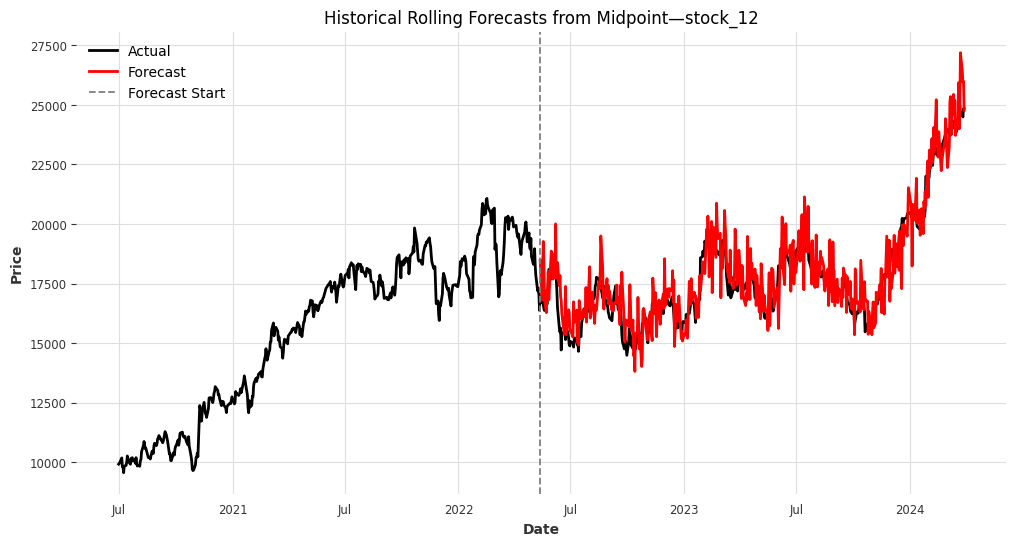

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_12: MAPE=4.12%, SMAPE=4.06%, MAE=724.2465


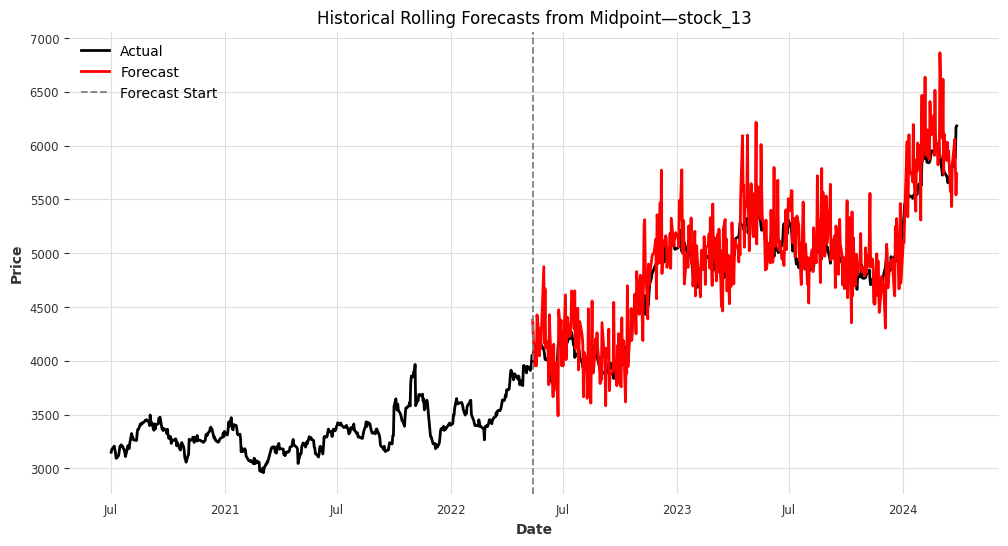

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_13: MAPE=4.55%, SMAPE=4.46%, MAE=218.9029


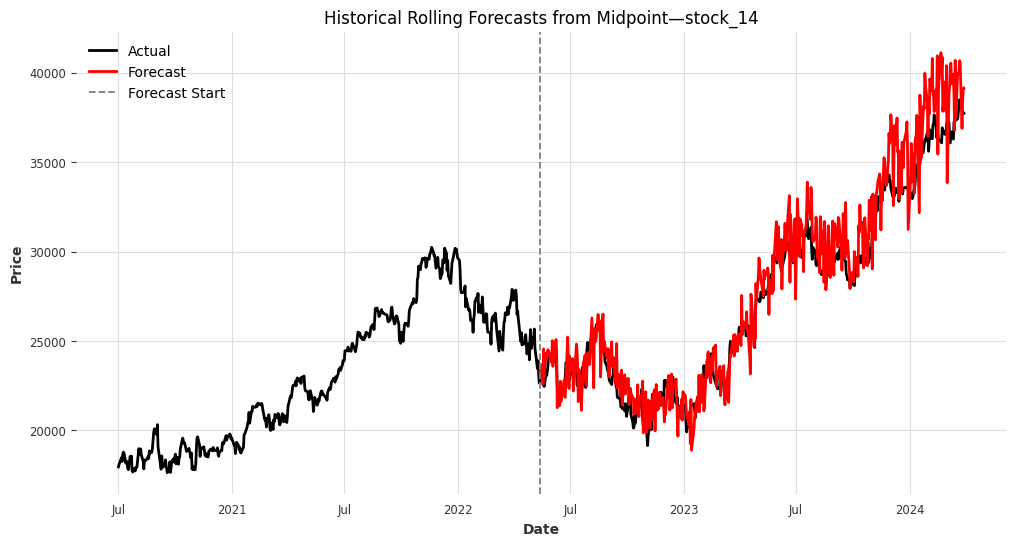

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_14: MAPE=4.31%, SMAPE=4.23%, MAE=1214.7604


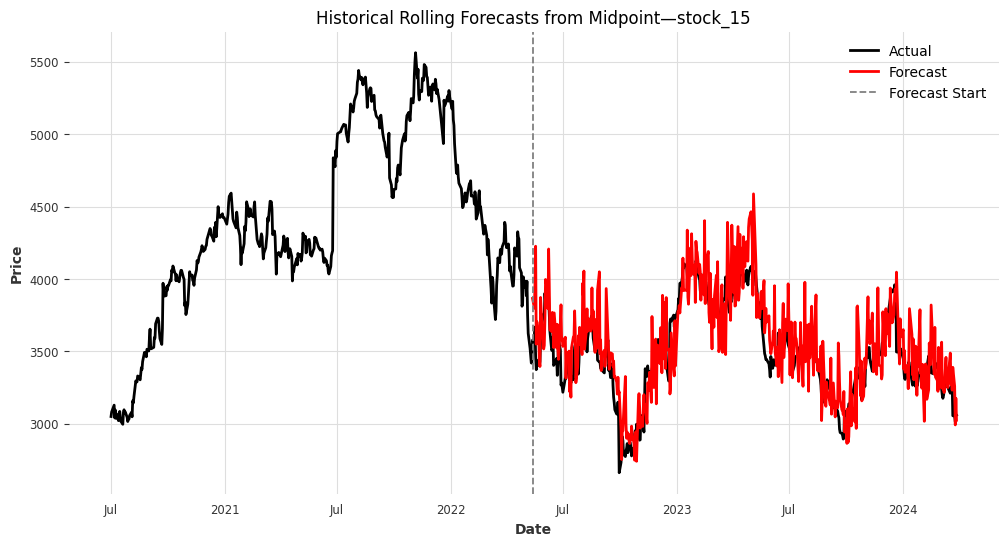

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_15: MAPE=4.66%, SMAPE=4.56%, MAE=160.9933


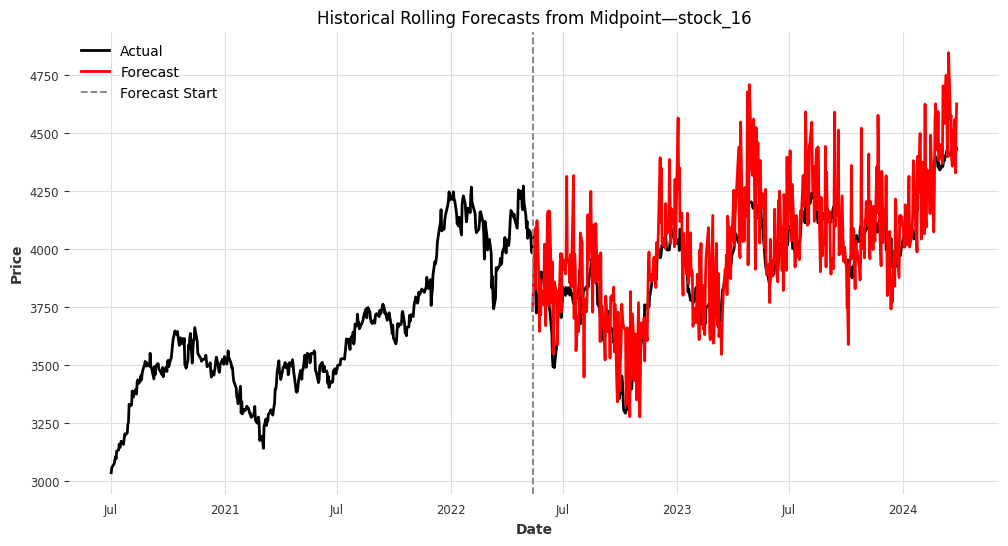

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_16: MAPE=3.71%, SMAPE=3.64%, MAE=145.6815


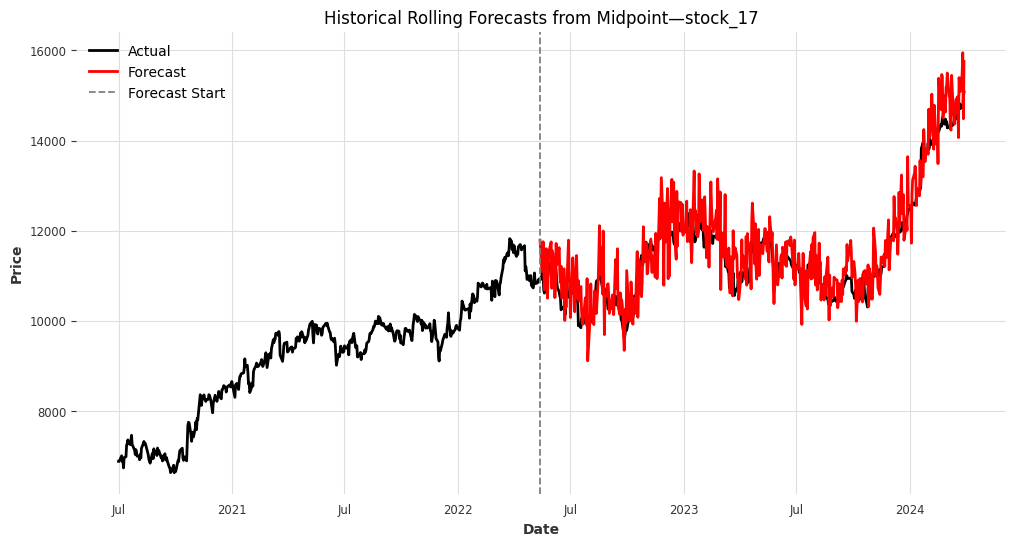

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_17: MAPE=3.76%, SMAPE=3.71%, MAE=431.5351


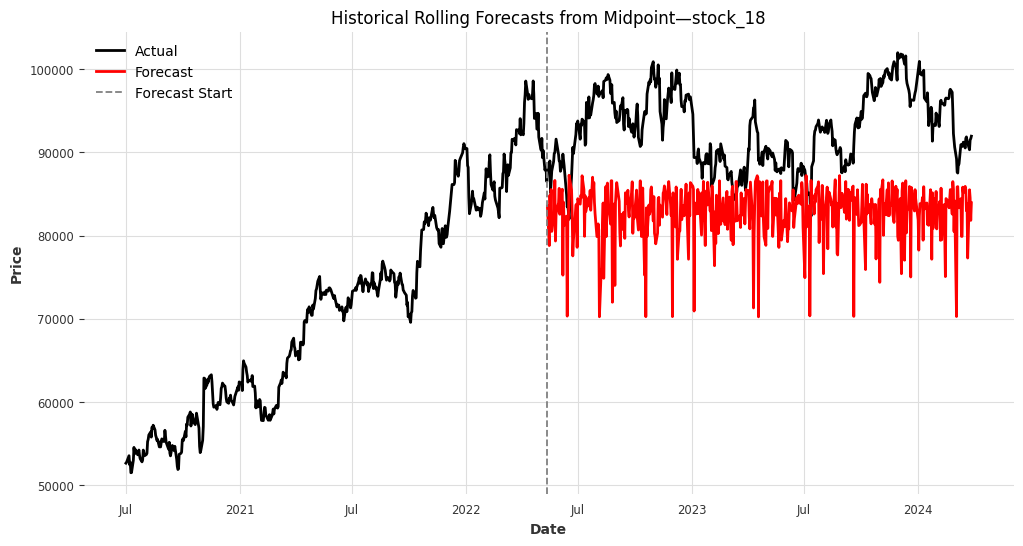

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_18: MAPE=10.78%, SMAPE=11.57%, MAE=10206.7686


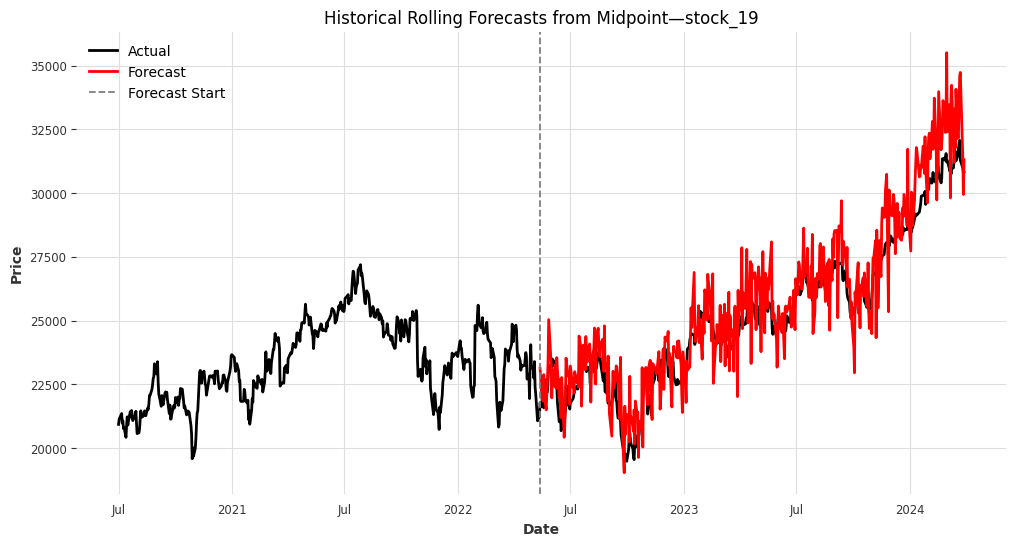

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_19: MAPE=3.80%, SMAPE=3.74%, MAE=962.9243


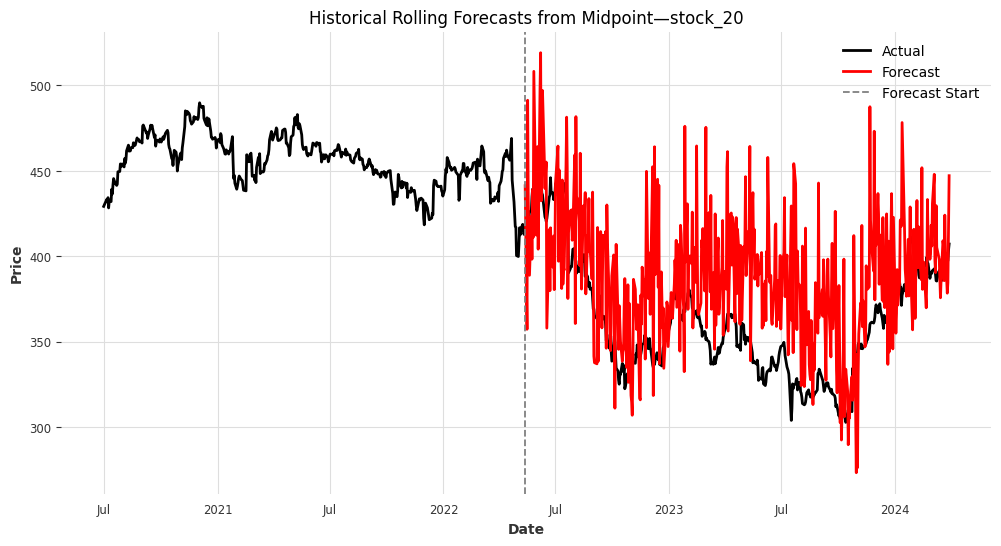

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_20: MAPE=10.41%, SMAPE=9.73%, MAE=36.8385


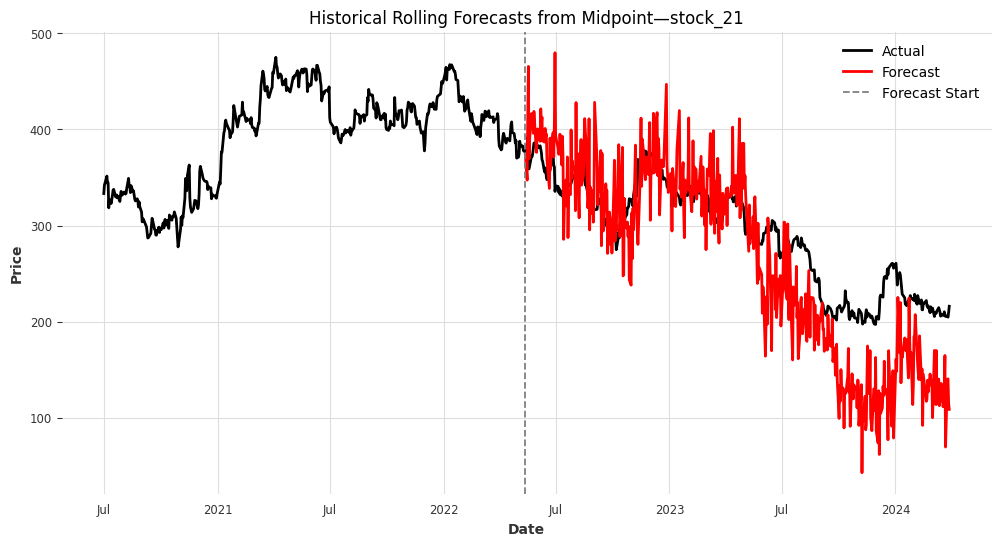

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_21: MAPE=18.64%, SMAPE=21.95%, MAE=47.8637


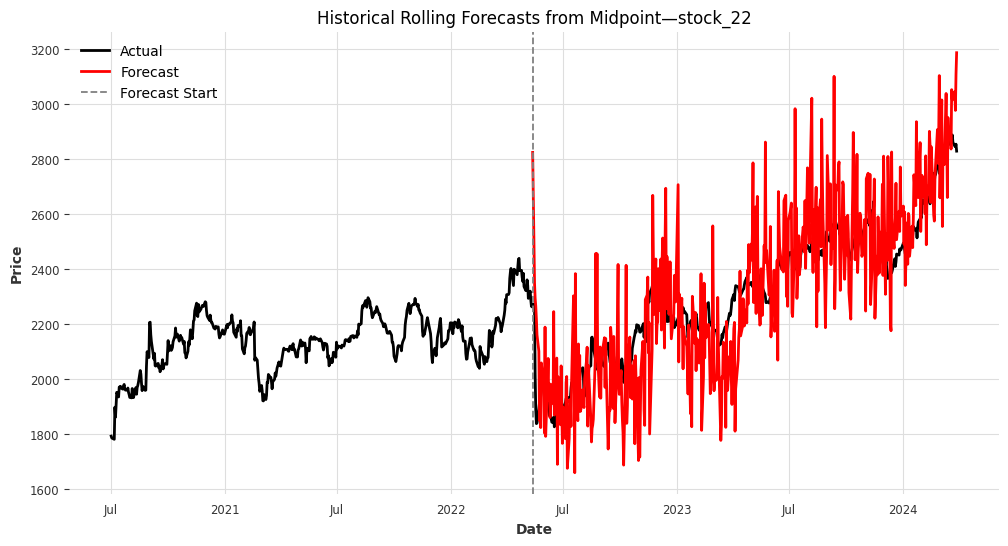

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_22: MAPE=6.50%, SMAPE=6.50%, MAE=148.5356


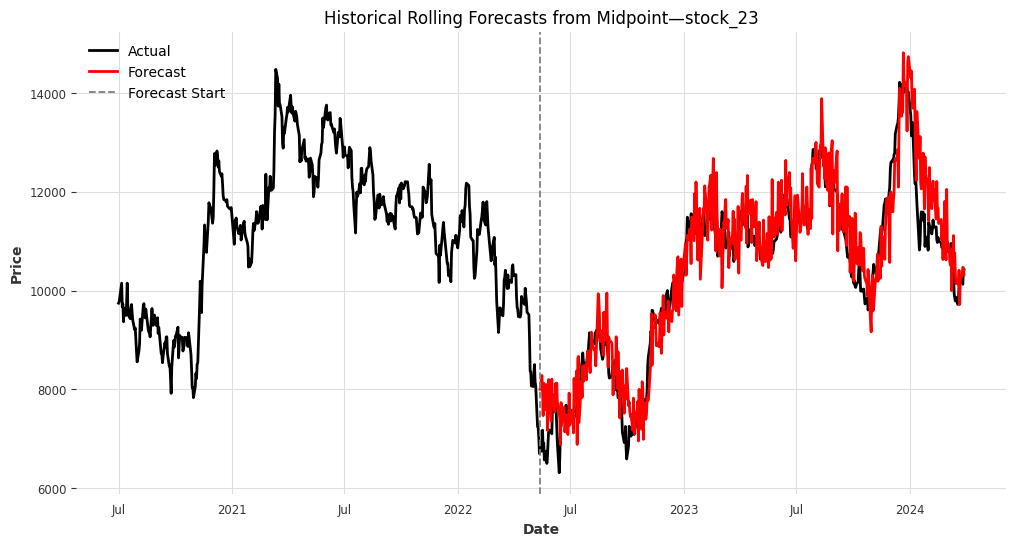

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_23: MAPE=4.93%, SMAPE=4.82%, MAE=487.9931


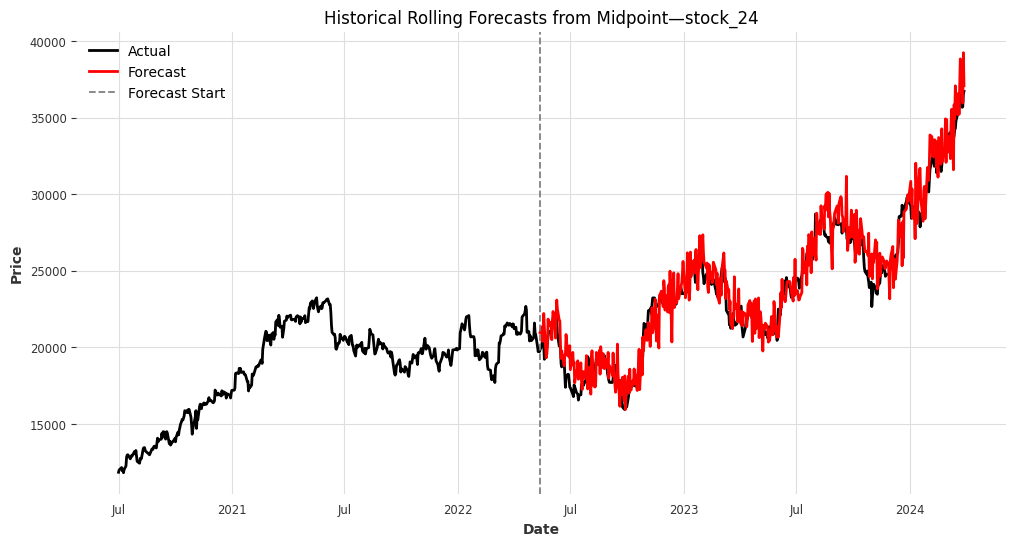

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_24: MAPE=4.22%, SMAPE=4.15%, MAE=984.5737


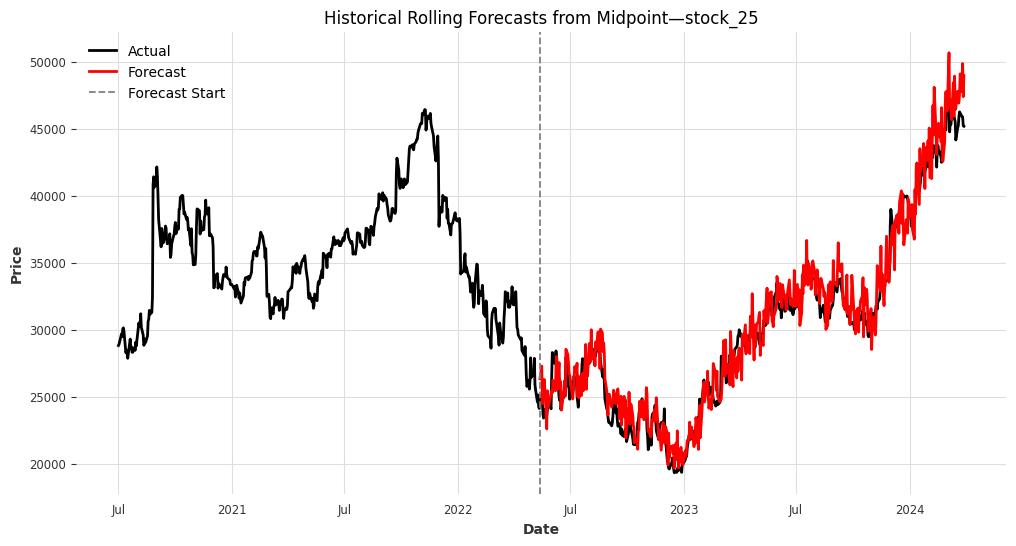

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_25: MAPE=4.08%, SMAPE=4.02%, MAE=1197.0123


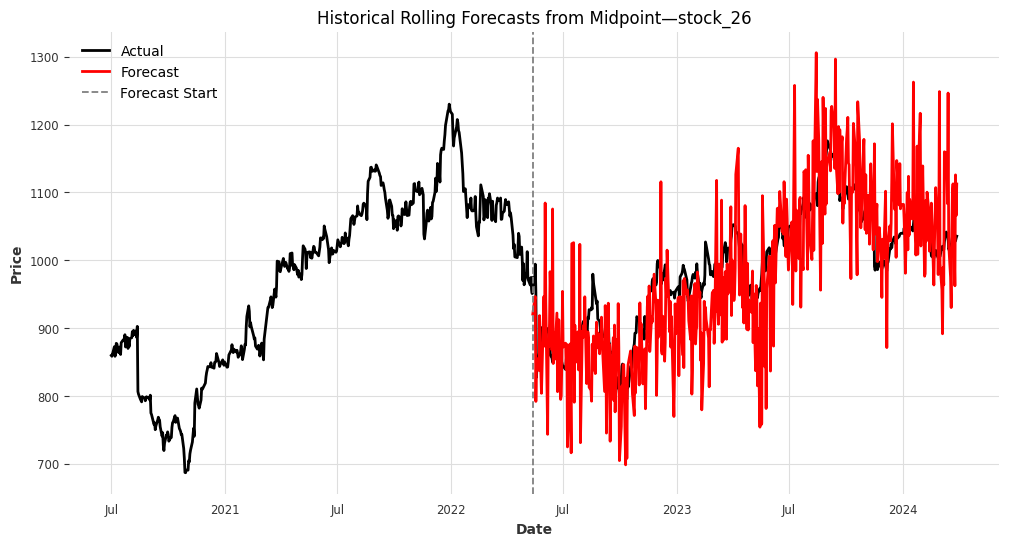

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_26: MAPE=6.18%, SMAPE=6.26%, MAE=60.7157


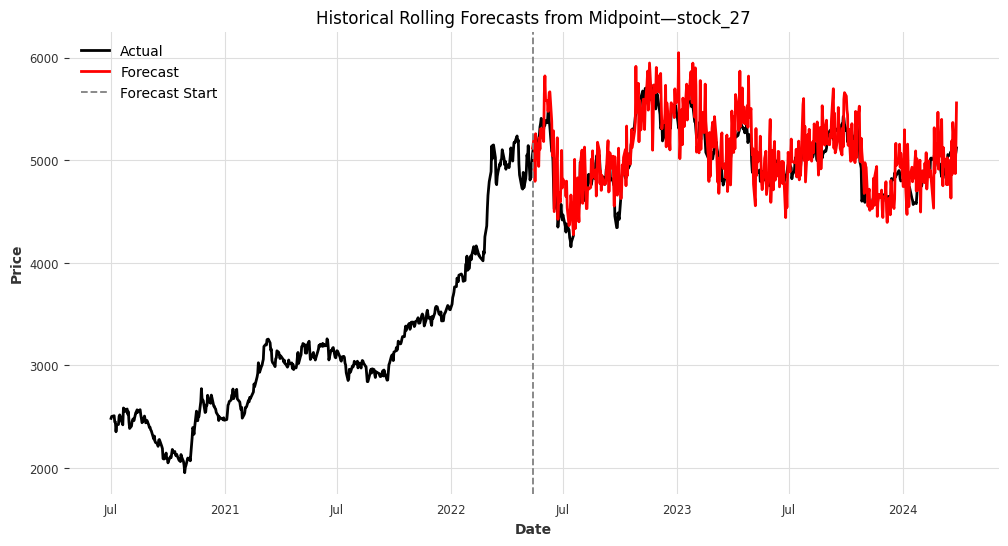

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_27: MAPE=3.75%, SMAPE=3.69%, MAE=186.6622


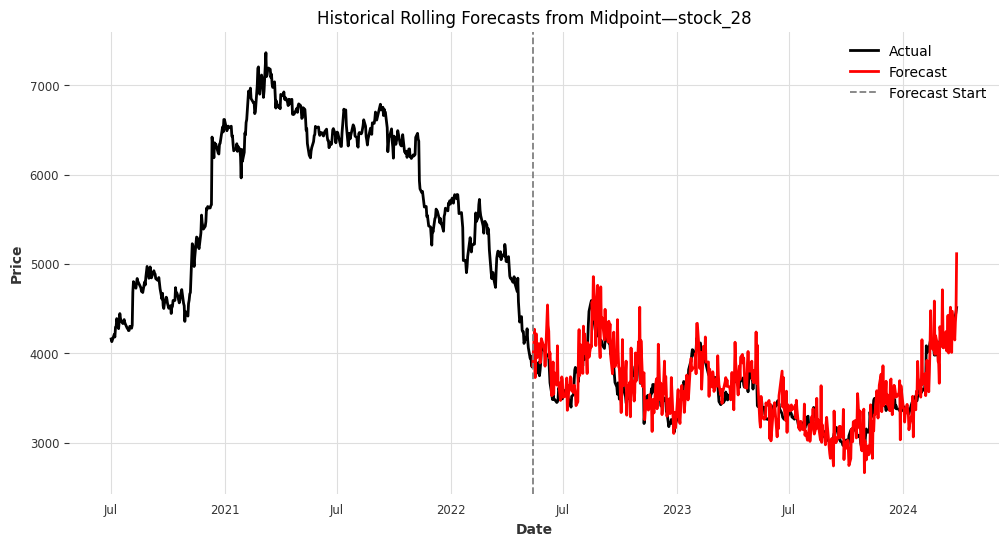

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Metrics stock_28: MAPE=4.85%, SMAPE=4.79%, MAE=174.1385


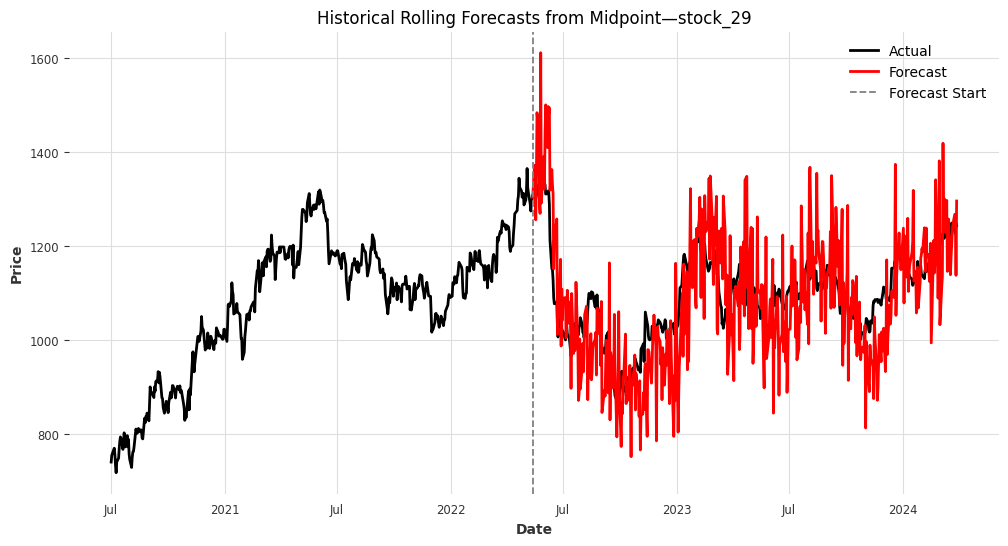

Metrics stock_29: MAPE=7.31%, SMAPE=7.39%, MAE=79.6611


In [12]:
from darts.metrics import mape, smape, mae

# fit scalers on train targets
scaler_dict = {i: Scaler().fit(ts) for i, ts in enumerate(train_target_list)}

for idx, ts_val in enumerate(val_target_list):
    # determine start date at midpoint
    mid_idx    = len(ts_val) // 2
    start_date = ts_val.time_index[mid_idx]

    # generate one-step historical forecasts from midpoint to end
    fc_hist = model.historical_forecasts(
        series=ts_val,
        past_covariates=val_past_cov_list[idx],
        start=start_date,
        forecast_horizon=1,
        stride=1,
        retrain=False,
        verbose=False,
    )

    # inverse scale
    actual_u   = scaler_dict[idx].inverse_transform(ts_val)
    forecast_u = scaler_dict[idx].inverse_transform(fc_hist)

    # plot actual and forecast
    plt.figure(figsize=(12,6))
    actual_u.plot(label='Actual', color='black')
    forecast_u.plot(label='Forecast', color='red')
    plt.axvline(start_date, color='grey', linestyle='--', label='Forecast Start')
    plt.title(f'Historical Rolling Forecasts from Midpoint—stock_{idx}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

    # metrics over forecast period
    common = forecast_u.time_index.intersection(actual_u.time_index)
    actual_sub = actual_u.slice(common[0], common[-1])
    pred_sub   = forecast_u
    print(
        f"Metrics stock_{idx}: MAPE={mape(actual_sub,pred_sub):.2f}%, "
        f"SMAPE={smape(actual_sub,pred_sub):.2f}%, MAE={mae(actual_sub,pred_sub):.4f}"
    )


## Save Trained Model

In [ ]:

# torch.save(model.state_dict(), 'multiplex_transformer.pth')


### Next Steps and Integration
- Add an evaluation loop on the validation/test split.
- Export the frozen Transformer to feed the RL environment.
- Experiment with different window/horizon sizes, LoRA ranks, and learning rates.